# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:

# información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ Comentario:

No se evidencian valores nulos o faltantes en ninguna de las columnas del conjunto de datos.

La columna converted puede transformarse a un tipo de dato booleano (True/False), lo que facilitará su interpretación y análisis, especialmente al evaluar las tasas de conversión.

La columna date debe convertirse al tipo de dato datetime, lo que permitirá realizar análisis temporales, como identificar tendencias, comparar periodos y analizar el comportamiento de las conversiones a lo largo del tiempo.

In [ ]:
#conversion de las columnas
df["converted"] = df["converted"].astype(bool)
df["date"] = pd.to_datetime(df["date"])

# Verificacion de informacion
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  bool          
 8   gasto           40000 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(1), object(6)
memory usage: 2.5+ MB


In [ ]:
#verificacion de conservacion de la informacion
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,True,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,False,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,False,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,False,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,False,0.00


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df['user_id'].duplicated().sum()

0

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

count     40000
unique        2
top       False
freq      34294
Name: converted, dtype: object

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


✍️ **Comentario**: 
La columna gasto presenta una distribución altamente sesgada hacia cero. Los tres cuartiles (25%, 50% y 75%) tienen un valor de 0, lo que indica que al menos el 75% de los registros presenta un gasto nulo. Por otro lado, el valor máximo es de 303.68, mientras que la media alcanza 9.33, superior a la mediana. Esta diferencia sugiere que los valores positivos, posiblemente concentrados en una proporción reducida de observaciones, influyen en el promedio. Se requiere un análisis adicional para determinar si la distribución corresponde al comportamiento esperado del negocio o si existen problemas de calidad de datos.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:

# Gasto por versión

gasto_A = df.loc[
    (df['landing'] == 'A') & (df['converted']),
    'gasto'
]

gasto_B = df.loc[
    (df['landing'] == 'B') & (df['converted']),
    'gasto'
]


# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [ ]:
gasto_A.mean(),gasto_B.mean()

(61.0865724522293, 68.74536005009392)

### Prueba T de Welch → equal_var=False

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia estadísticamente significativa entre el gasto promedio de los usuarios de Landing A y Landing B.
- **Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa entre el gasto promedio de los usuarios de Landing A y Landing B

In [ ]:
from scipy.stats import levene

# Ejecutar prueba de Levene y mostrar resultados
l_stat, p_value_var = levene(gasto_A, gasto_B, center='median')
print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")
alpha = 0.05
if p_value_var < alpha:
    print("Se rechaza la hipotesis nula, lo que respalda la utilizacion de t de Welch")
else:
    print("Se rechazó la hipótesis nula, lo que indica evidencia estadística de una diferencia entre las varianzas de ambos grupos.")

Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08
Se rechazó la hipótesis nula, lo que indica evidencia estadística de una diferencia entre las varianzas de ambos grupos.


In [ ]:
from scipy.stats import ttest_ind
# Aplicar prueba
stat, p_value = ttest_ind(
    gasto_A,
    gasto_B,
    equal_var=False
)

# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


Se rechazó la hipótesis nula, lo que indica evidencia estadística de una diferencia entre las varianzas de ambos grupos. Por esta razón, se utilizó la prueba t de Welch (equal_var=False), que no asume igualdad de varianzas.

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula.")
    print("Existe evidencia de una diferencia estadísticamente significativa.")
else:
    print("No se rechaza la hipótesis nula.")
    print("No hay evidencia suficiente de una diferencia estadísticamente significativa.")

Se rechaza la hipótesis nula.
Existe evidencia de una diferencia estadísticamente significativa.


In [ ]:
media_A = gasto_A.mean()
media_B = gasto_B.mean()

diferencia = media_B - media_A

print("Gasto promedio A:", media_A)
print("Gasto promedio B:", media_B)
print("Diferencia de gasto:", diferencia)

Gasto promedio A: 61.0865724522293
Gasto promedio B: 68.74536005009392
Diferencia de gasto: 7.658787597864624


### 📝 Conclusión e interpretación

**Decisión estadística:**

Se rechaza la hipótesis nula (H₀), utilizando un nivel de significancia de α = 0.05, debido a que el p-value obtenido (`3.6e-21`) es considerablemente inferior al nivel de significancia establecido.

**Interpretación estadística:**

El test de Welch presenta un estadístico t de `-9.48` y un p-value de `3.6e-21`, lo que proporciona evidencia estadística de una diferencia en el gasto promedio entre los usuarios de Landing A y Landing B, bajo los supuestos de la prueba.

**Interpretación de negocio:**

En la muestra analizada, el gasto promedio de los usuarios de Landing A fue de `61.08`, mientras que el de Landing B fue de `68.74`. Esto representa una diferencia aproximada de `7.66` unidades monetarias a favor de la versión B.

Los resultados indican una diferencia estadísticamente significativa entre los grupos. No obstante, la significancia estadística no implica necesariamente que la diferencia tenga una relevancia económica importante, ni demuestra por sí sola que el diseño de Landing B sea la causa del mayor gasto. Para complementar el análisis, sería conveniente evaluar el tamaño del efecto, los intervalos de confianza y el diseño del experimento A/B.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z de proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe evidencia estadisticamente significativa en la conversion de los usuarios de Landing A y Landing B
- **Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa entre la conversion de los usuarios de Landing A y Landing B

In [ ]:


# Usuarios por landing
landing_A = df[df['landing'] == 'A']
landing_B = df[df['landing'] == 'B']

# Número de usuarios
total_A = len(landing_A)
total_B = len(landing_B)

# Número de conversiones
converted_A = landing_A['converted'].sum()
converted_B = landing_B['converted'].sum()

# Tasa de conversión
conversion_A = converted_A / total_A
conversion_B = converted_B / total_B

print(f"Landing A: {converted_A} conversiones de {total_A} usuarios")
print(f"Tasa de conversión A: {conversion_A:.2%}")

print(f"\nLanding B: {converted_B} conversiones de {total_B} usuarios")
print(f"Tasa de conversión B: {conversion_B:.2%}")

# Diferencia de tasas
difference = conversion_B - conversion_A

print(f"\nDiferencia de conversión: {difference:.2%}")



Landing A: 2512 conversiones de 19982 usuarios
Tasa de conversión A: 12.57%

Landing B: 3194 conversiones de 20018 usuarios
Tasa de conversión B: 15.96%

Diferencia de conversión: 3.38%


In [ ]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

# Conversiones
successes = [converted_A, converted_B]

# Total de usuarios
observations = [total_A, total_B]

# Test de dos proporciones
stat, p_value = proportions_ztest(
    count=successes,
    nobs=observations
)

# Visualizar resultados
print(f"Estadístico z: {stat:.4f}")
print(f"P-value: {p_value:.4e}")

Estadístico z: -9.6774
P-value: 3.7630e-22


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula.")
    print("Existe evidencia estadística de una diferencia entre las tasas de conversión.")
else:
    print("No se rechaza la hipótesis nula.")
    print("No hay evidencia estadística suficiente para afirmar una diferencia entre las tasas de conversión.")

Se rechaza la hipótesis nula.
Existe evidencia estadística de una diferencia entre las tasas de conversión.


### 📝 Conclusión e interpretación

**Decisión estadística:**

Se rechaza la hipótesis nula (H₀), utilizando un nivel de significancia de α = 0.05, debido a que el p-value obtenido (`3.76e-22`) es considerablemente inferior al nivel de significancia establecido.

**Interpretación estadística:**

El test de dos proporciones presenta un estadístico z de `-9.6` y un p-value de `3.76e-22`. Este resultado proporciona evidencia estadística suficiente para rechazar la hipótesis nula de igualdad entre las tasas de conversión de Landing A y Landing B.

**Interpretación de negocio:**

La Landing A presenta una tasa de conversión del `12.57%`, mientras que la Landing B alcanza una tasa de `15.96%`. La diferencia observada es de aproximadamente **3.38 puntos porcentuales** a favor de la Landing B.

Por lo tanto, en la muestra analizada, se observa una diferencia estadísticamente significativa entre las tasas de conversión de ambas versiones, siendo la tasa de conversión de la Landing B superior a la de la Landing A.

Este resultado indica una diferencia estadísticamente significativa entre las dos versiones, pero la significancia estadística por sí sola no determina la magnitud ni la relevancia económica del efecto. Para complementar el análisis, sería conveniente calcular el intervalo de confianza y la diferencia relativa entre ambas tasas.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** la fuente de tráfico y la conversión son independientes; la tasa de conversión no depende de la fuente.
- **Hipótesis alternativa (H₁):** existe una asociación entre la fuente de tráfico y la conversión.

In [ ]:
from scipy.stats import chi2_contingency

tabla_ts_c = pd.crosstab(df['traffic_source'], df['converted'])

print(tabla_ts_c)

converted       False  True 
traffic_source              
Ads             10176   1759
Email            5205    918
Organic         15507   2480
Referral         3406    549


In [ ]:
# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla_ts_c)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"P-value: {p_value:.4e}")

Chi-cuadrado: 8.6621
P-value: 3.4138e-02


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula.")
    print("Existe evidencia de una asociación entre la fuente de tráfico y la conversión.")
else:
    print("No se rechaza la hipótesis nula.")
    print("No hay evidencia suficiente para afirmar una asociación entre la fuente de tráfico y la conversión.")

Se rechaza la hipótesis nula.
Existe evidencia de una asociación entre la fuente de tráfico y la conversión.


In [ ]:
conversion_por_fuente = df.groupby('traffic_source')['converted'].agg(
    conversiones='sum',
    usuarios='count'
)

conversion_por_fuente['tasa_conversion'] = (
    conversion_por_fuente['conversiones'] /
    conversion_por_fuente['usuarios']
)

print(conversion_por_fuente)

                conversiones  usuarios  tasa_conversion
traffic_source                                         
Ads                     1759     11935         0.147382
Email                    918      6123         0.149927
Organic                 2480     17987         0.137877
Referral                 549      3955         0.138812


### 📝 Conclusión e interpretación

**Decisión estadística:**

Se rechaza la hipótesis nula (H₀), utilizando un nivel de significancia de α = 0.05, debido a que el p-value obtenido (`3.41e-02`, equivalente a `0.0341`) es inferior al nivel de significancia establecido.

**Interpretación estadística:**

El resultado del test de chi-cuadrado proporciona evidencia estadística suficiente para afirmar que existe una asociación entre la fuente de tráfico y la conversión. Por lo tanto, las variables `source` y `converted` no se comportan como variables independientes en la muestra analizada.

**Interpretación de negocio:**

Las tasas de conversión observadas según la fuente de tráfico fueron:

* Ads: **14.7%**
* Email: **14.9%**
* Organic: **13.7%**
* Referral: **13.8%**

Se observan diferencias en las tasas de conversión entre las distintas fuentes. Sin embargo, la magnitud de estas diferencias es relativamente pequeña: la diferencia entre la tasa más alta (Email, 14.9%) y la más baja (Organic, 13.7%) es de aproximadamente **1.2 puntos porcentuales**.

Esto indica que, aunque existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión, el tamaño de las diferencias observadas es reducido en términos absolutos. Por esta razón, la significancia estadística no debe interpretarse automáticamente como un impacto de gran relevancia para el negocio.

Además, el test de chi-cuadrado evalúa la asociación de manera global y no permite determinar por sí solo entre qué fuentes se encuentran las diferencias estadísticamente significativas. Para profundizar en el análisis, sería conveniente realizar comparaciones post-hoc y evaluar el tamaño del efecto.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** la recurrencia del usuario y la conversión son independientes; la tasa de conversión no depende de la recurrencia.
- **Hipótesis alternativa (H₁):** existe una asociación entre la recurrencia del cliente y la conversión.

In [ ]:
tabla = pd.crosstab(df['user_type'], df['converted'])

print(tabla)

converted   False  True 
user_type               
Nuevo       22295   3738
Recurrente  11999   1968


In [ ]:
conversion_por_tipo = df.groupby('user_type')['converted'].agg(
    conversiones='sum',
    usuarios='count'
)

conversion_por_tipo['tasa_conversion'] = (
    conversion_por_tipo['conversiones'] /
    conversion_por_tipo['usuarios']
)

print(conversion_por_tipo)

            conversiones  usuarios  tasa_conversion
user_type                                          
Nuevo               3738     26033         0.143587
Recurrente          1968     13967         0.140904


In [ ]:
# Aplicar prueba
chi2, p_value, dof, expected = chi2_contingency(tabla)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"P-value: {p_value:.4e}")


Chi-cuadrado: 0.5135
P-value: 4.7363e-01


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula.")
    print("Existe evidencia de una asociación entre el tipo de usuario y la conversión.")
else:
    print("No se rechaza la hipótesis nula.")
    print("No hay evidencia suficiente para afirmar una asociación entre el tipo de usuario y la conversión.")

No se rechaza la hipótesis nula.
No hay evidencia suficiente para afirmar una asociación entre el tipo de usuario y la conversión.


### 📝 Conclusión e interpretación

**Decisión estadística:**

No se rechaza la hipótesis nula (H₀), utilizando un nivel de significancia de α = 0.05, debido a que el p-value obtenido (`4.73e-01`, equivalente a `0.473`) es superior al nivel de significancia establecido.

**Interpretación estadística:**

El resultado del test de chi-cuadrado no proporciona evidencia estadística suficiente para afirmar que exista una asociación entre el tipo de usuario (`user_type`) y la conversión (`converted`) en la muestra analizada.

Esto significa que, con los datos disponibles y bajo el nivel de significancia establecido, no se puede rechazar la hipótesis de que ambas variables sean independientes. Sin embargo, esto no demuestra que no exista ninguna relación entre ellas; simplemente indica que no se encontró evidencia estadística suficiente para establecerla.

**Interpretación de negocio:**

La tasa de conversión de los usuarios nuevos fue de **14.30%**, mientras que la de los usuarios recurrentes fue de **14.09%**. La diferencia observada es de aproximadamente **0.21 puntos porcentuales**, lo que representa una diferencia pequeña entre ambos grupos.

En consecuencia, además de no encontrarse evidencia estadística suficiente de una asociación entre la recurrencia y la conversión, la magnitud de la diferencia observada también es reducida. Con la información analizada, la recurrencia del usuario no muestra una diferencia relevante en la tasa de conversión.


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

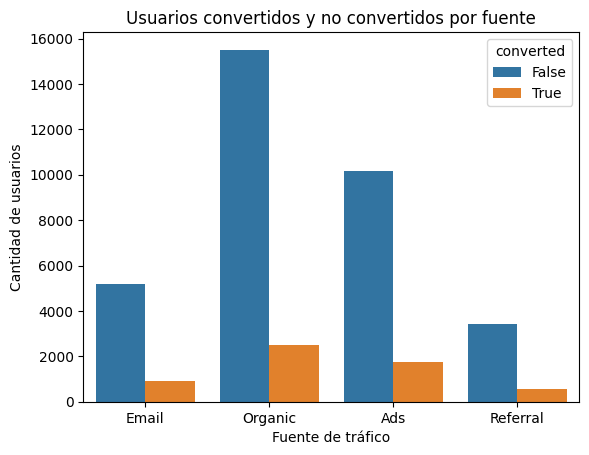

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='traffic_source', hue='converted')

plt.title('Usuarios convertidos y no convertidos por fuente')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.show()

✍️ **Comentario:**
En el gráfico se observa la cantidad de usuarios convertidos (`True`) y no convertidos (`False`) según la fuente de tráfico. La fuente **Organic** concentra el mayor volumen de usuarios, con cerca de 16.000, y también presenta el mayor número absoluto de conversiones, con aproximadamente 3.000 usuarios convertidos.

Le sigue **Ads**, que registra un volumen de usuarios ligeramente superior a 10.000 y alrededor de 1.500 conversiones. Por otro lado, **Referral** presenta el menor volumen de usuarios, con menos de 4.000, y aproximadamente 800 conversiones.

En términos de volumen absoluto, **Organic genera la mayor cantidad de conversiones**, mientras que **Referral presenta el menor número de conversiones**.


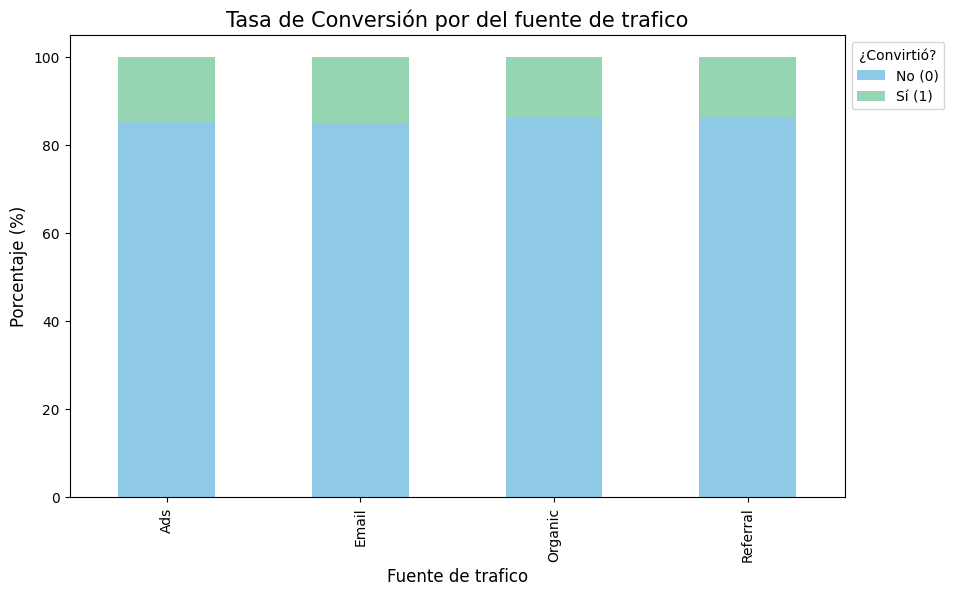

In [ ]:
tabla_ts_c = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_ts_c.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por la fuente de trafico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de trafico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show() 


✍️ **Comentario:**
A partir de la gráfica de barras apiladas se observa que las proporciones de usuarios convertidos y no convertidos son muy similares entre las diferentes fuentes de tráfico. Visualmente, no se aprecia una diferencia relevante en términos porcentuales, lo que sugiere que la fuente de tráfico podría tener un efecto limitado sobre la tasa de conversión.


### Relación entre el tipo de usuario y la conversión

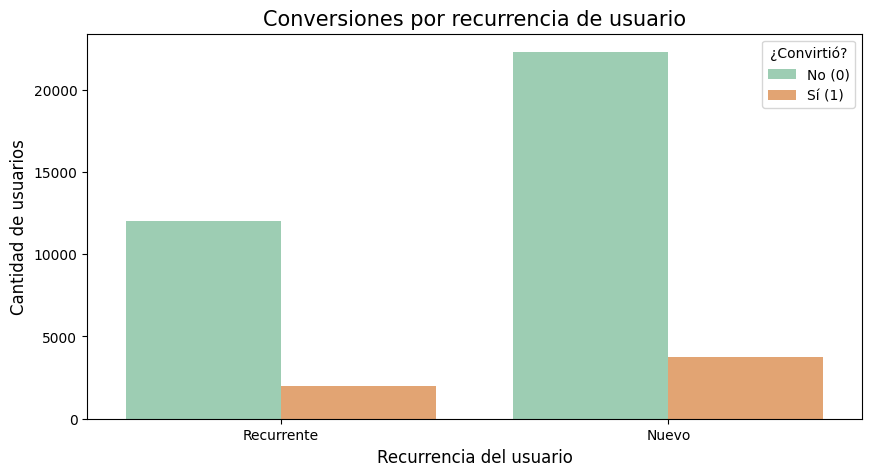

In [ ]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles
plt.title('Conversiones por recurrencia de usuario', fontsize=15)
plt.xlabel('Recurrencia del usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario:**
En la gráfica se observa que los usuarios nuevos representan el mayor volumen de usuarios, con aproximadamente **25.000 usuarios**, de los cuales cerca de **5.000 realizaron una conversión**. Por su parte, los usuarios recurrentes representan aproximadamente **13.000 usuarios**, con menos de **2.500 conversiones**.
Aunque los usuarios nuevos presentan un mayor número absoluto de conversiones, esta diferencia está relacionada principalmente con el mayor volumen de usuarios de esta categoría.


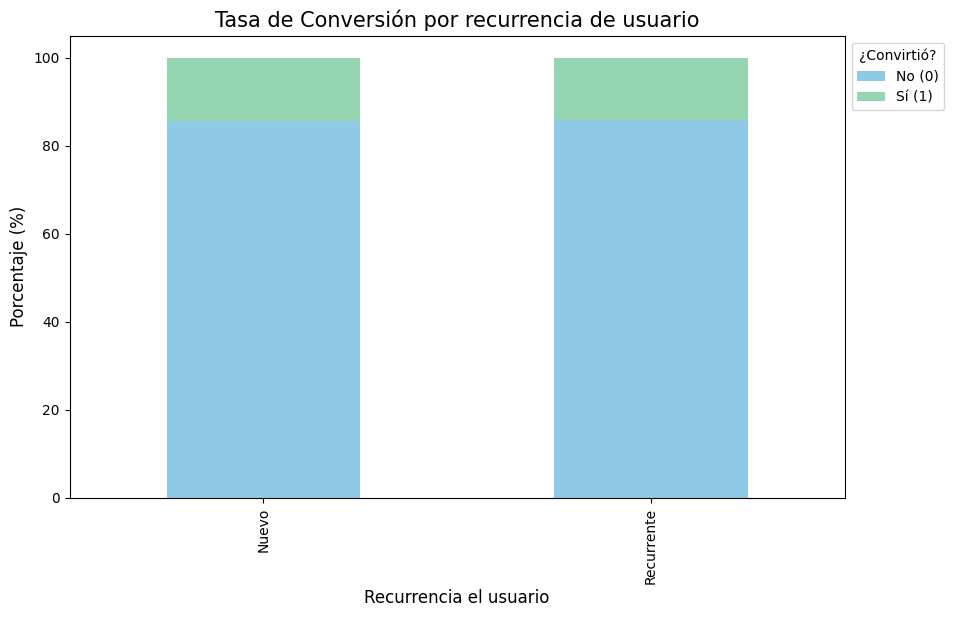

In [ ]:
table_ut_c = pd.crosstab(df['user_type'],df['converted'],normalize='index')*100

# Gráfica de barras apiladas
table_ut_c.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por recurrencia de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Recurrencia el usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

✍️ **Comentario:**
Visualmente, en la gráfica de barras apiladas no se observa una diferencia relevante entre las tasas de conversión de los usuarios nuevos y recurrentes. Las proporciones de usuarios convertidos y no convertidos son muy similares entre ambos tipos de usuario.


### Relación entre la conversion y el landing

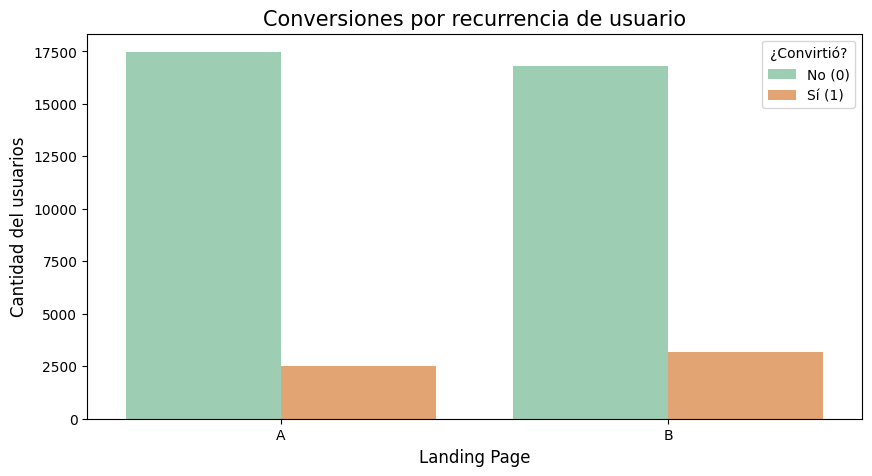

In [ ]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='landing', hue='converted', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles
plt.title('Conversiones segun la lading page', fontsize=15)
plt.xlabel('Landing Page', fontsize=12)
plt.ylabel('Cantidad del usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario:**

En la grafica se observa la distribucion de clientes que entraron por landing, tanto a como B presentan una distribucion similar entre los 17.500 y poco menos, sin enbargo en la conversion (Si), Landing B representa una proporcion ligeramente mayor que el Landing A


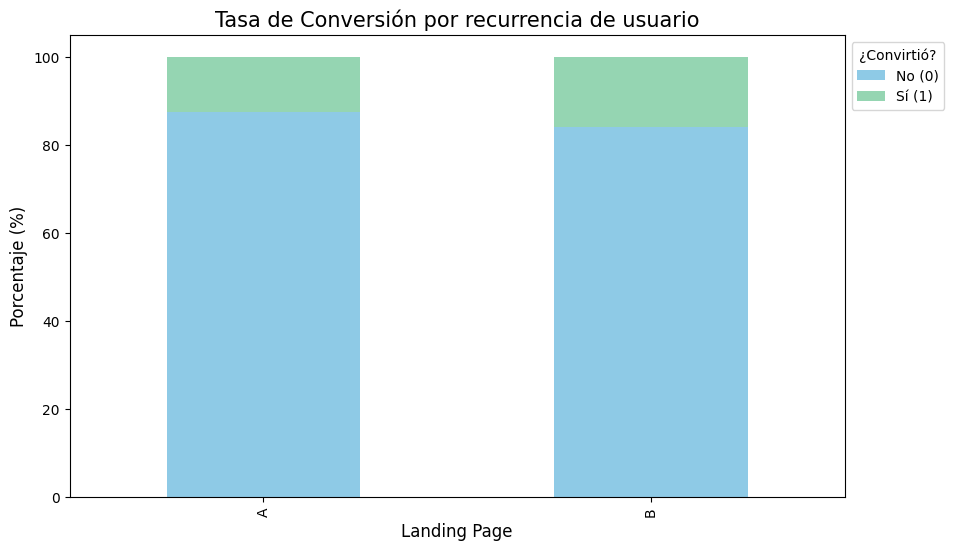

In [ ]:
table_ut_c = pd.crosstab(df['landing'],df['converted'],normalize='index')*100

# Gráfica de barras apiladas
table_ut_c.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión segun landing page', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Landing Page', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

✍️ **Comentario:**
La grafica de barras apiladas presenta una diferenciacion muy sutil pero significativa en como Landing page B tiene en termino porcentuales una mayor cantidad de conversion (Si), en comparacion de la landing A

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

A partir del análisis del experimento A/B se consolidan los principales hallazgos relacionados con la versión de la landing page, la conversión, el gasto promedio, las fuentes de tráfico y el tipo de usuario.

### 1. ¿Qué página genera mayor conversión y gasto promedio?

La **Landing B** presenta mejores resultados en ambas métricas analizadas.
Las pruebas estadísticas realizadas muestran evidencia suficiente para rechazar la hipótesis nula de igualdad entre las versiones, tanto para el gasto promedio como para la tasa de conversión. Por lo tanto, dentro de las condiciones y datos analizados, la **Landing B presenta un mejor desempeño observado**.

### 2. ¿Qué canales de tráfico son más efectivos para generar conversiones?

Se analizaron cuatro fuentes de tráfico: **Ads, Email, Organic y Referral**.

La prueba de independencia obtuvo un **p-value de 0,0341**, inferior al nivel de significancia de 0,05. Esto proporciona evidencia estadística de una asociación entre la fuente de tráfico y la conversión.


Sin embargo, las diferencias observadas en las tasas de conversión son pequeñas

La diferencia entre la tasa más alta y la más baja es de aproximadamente **1,2 puntos porcentuales**. Por tanto, aunque existe evidencia estadística de una asociación, el tamaño de la diferencia entre las fuentes es reducido y su relevancia para el negocio debería evaluarse considerando también el volumen de usuarios y el costo de adquisición de cada canal.


### 3. ¿Existen diferencias significativas según el tipo de usuario?

Los usuarios nuevos representan un volumen considerablemente mayor que los usuarios recurrentes y también generan un mayor número absoluto de conversiones.
Sin embargo, al analizar las tasas de conversión, la diferencia es mínima:


La prueba de chi-cuadrado obtuvo un **p-value de 0,473**, superior a 0,05. Por lo tanto, no se encontró evidencia estadística suficiente para afirmar que exista una asociación entre el tipo de usuario y la conversión.

Esto indica que el mayor número absoluto de conversiones de los usuarios nuevos está principalmente relacionado con que este grupo tiene un mayor volumen de usuarios, y no con una diferencia relevante en su tasa de conversión.

### 4. Recomendaciones para optimizar la estrategia de marketing

Los resultados sugieren que la **Landing B merece especial atención**, ya que presentó mayores valores tanto en gasto promedio como en tasa de conversión dentro del experimento analizado.

En cuanto a las fuentes de tráfico, las diferencias porcentuales son relativamente pequeñas. Por ello, en lugar de tomar decisiones únicamente a partir de la tasa de conversión, sería conveniente complementar el análisis con variables como:

* costo de adquisición por canal;
* gasto o ingreso generado por usuario;
* dispositivo utilizado;
* región o ubicación;
* comportamiento dentro de la página;
* tipo de producto adquirido;
* tiempo hasta la conversión.

También sería importante profundizar en el comportamiento de los **usuarios recurrentes**. Aunque su tasa de conversión es muy similar a la de los usuarios nuevos, representan un volumen considerablemente menor. Esto plantea una oportunidad de investigación: determinar si existen factores que dificultan que un usuario vuelva a interactuar con la plataforma después de su primera visita o compra.

En conjunto, los resultados muestran que la versión de la landing page presenta una diferencia más marcada que las variables relacionadas con la procedencia o recurrencia del usuario. Por ello, futuros análisis podrían centrarse en identificar **qué características de la experiencia del usuario explican las diferencias de conversión y gasto**, y utilizar esta información para realizar segmentaciones más precisas y diseñar estrategias de marketing basadas en evidencia.


### 🌟 Insight Ejecutivo basado en el Experimento A/B

El análisis del experimento A/B permitió identificar diferencias principalmente asociadas a la **versión de la landing page**, mientras que las variables relacionadas con la fuente de tráfico y el tipo de usuario presentan diferencias porcentuales mucho más pequeñas.

---

#### 🔍 Comparación de página: Landing A vs. Landing B

**Gasto promedio por usuario que convirtió:**

* **Landing A:** 61,09
* **Landing B:** 68,75
* **Diferencia:** 7,66

**Interpretación:**
La Landing B presenta un gasto promedio superior al de la Landing A. La prueba estadística realizada encontró evidencia suficiente para considerar que esta diferencia es estadísticamente significativa. Esto indica que, dentro de los datos analizados, los usuarios que convirtieron en la Landing B presentan un mayor gasto promedio.

**Tasa de conversión:**

* **Landing A:** 12,57%
* **Landing B:** 15,96%
* **Diferencia:** 3,38 puntos porcentuales

**Interpretación:**
La Landing B también presenta una tasa de conversión superior. La diferencia de **3,38 puntos porcentuales** representa un aumento relativo aproximado del **26,9% respecto a la tasa de Landing A**.

En conjunto, estos resultados hacen que la versión de la landing page sea la variable que presenta la diferencia más marcada dentro del análisis realizado.

---

#### 📊 Segmentación por fuente de tráfico

Las tasas de conversión observadas fueron:

* **Email:** 14,9%
* **Ads:** 14,7%
* **Referral:** 13,8%
* **Organic:** 13,7%

La prueba de chi-cuadrado obtuvo un **p-value de 0,0341**, inferior al nivel de significancia de 0,05. Por lo tanto, existe evidencia estadística de una asociación entre la fuente de tráfico y la conversión.

Sin embargo, la diferencia entre la tasa de conversión más alta y la más baja es de apenas **1,2 puntos porcentuales**. Esto indica que, aunque existe una diferencia estadísticamente detectable, las tasas de conversión entre las fuentes son relativamente similares.

Por esta razón, la decisión sobre dónde concentrar recursos de marketing no debería basarse únicamente en la tasa de conversión. También sería necesario considerar el **volumen de usuarios, costo de adquisición, gasto generado e ingreso por usuario** de cada canal.

---

#### 📊 Segmentación por tipo de usuario

Las tasas de conversión fueron:

* **Usuarios nuevos:** 14,30%
* **Usuarios recurrentes:** 14,09%
* **Diferencia:** 0,21 puntos porcentuales

Aunque los usuarios nuevos generan un mayor número absoluto de conversiones, esto ocurre principalmente porque representan un volumen mucho mayor de usuarios.

La prueba de chi-cuadrado obtuvo un **p-value de 0,473**, superior a 0,05. Por lo tanto, **no se encontró evidencia estadística suficiente para afirmar que exista una asociación entre el tipo de usuario y la conversión**.

Además, la diferencia de apenas **0,21 puntos porcentuales** entre ambos grupos refuerza la idea de que, dentro de los datos analizados, el tipo de usuario no representa una diferencia relevante en la tasa de conversión.

No obstante, el menor volumen de usuarios recurrentes constituye un punto interesante para investigaciones posteriores, especialmente para entender qué factores favorecen o dificultan que un usuario vuelva a interactuar con la plataforma.

---

#### 💡 Recomendaciones de negocio

A partir de los resultados obtenidos, se proponen las siguientes líneas de análisis:

1. **Profundizar en el desempeño de la Landing B.**
   Analizar qué elementos de esta versión podrían estar relacionados con la mayor tasa de conversión y el mayor gasto promedio observado. Esto permitiría identificar oportunidades para optimizar la experiencia de usuario.

2. **Analizar el comportamiento de los usuarios recurrentes.**
   Aunque su tasa de conversión es similar a la de los usuarios nuevos, su volumen es considerablemente menor. Sería útil investigar variables como frecuencia de visita, tiempo entre interacciones, productos consultados y comportamiento antes de abandonar la página.

3. **Segmentar por dispositivo y región.**
   Analizar si existen diferencias en conversión y gasto promedio según dispositivo, región u otras características del usuario podría permitir identificar segmentos con comportamientos particulares o posibles puntos de fricción.

4. **Analizar características comunes entre usuarios que convierten.**
   Identificar patrones compartidos entre los usuarios convertidos —por ejemplo, fuente de tráfico, dispositivo, región, edad o comportamiento dentro de la página— podría ayudar a detectar segmentos con mayor probabilidad de conversión.

5. **Evaluar los canales considerando tanto conversión como rentabilidad.**
   Las diferencias entre fuentes de tráfico son pequeñas en términos de conversión, por lo que sería necesario incorporar variables económicas como costo de adquisición, gasto promedio e ingreso generado para determinar el verdadero rendimiento de cada canal.

### 🎯 Conclusión general

El principal hallazgo del experimento es la **diferencia observada entre las dos versiones de la landing page**: la Landing B presenta tanto una mayor tasa de conversión como un mayor gasto promedio. En contraste, las diferencias asociadas al tipo de usuario son mínimas, mientras que las fuentes de tráfico muestran una asociación estadística con la conversión, pero con diferencias porcentuales relativamente pequeñas.

Por ello, los siguientes análisis deberían enfocarse en comprender **qué características de la Landing B están relacionadas con su mejor desempeño** y en identificar, mediante una segmentación más profunda, qué factores del usuario y de su experiencia pueden explicar las diferencias de comportamiento observadas.
